<a href="https://colab.research.google.com/github/alex-smith-uwec/CS491/blob/main/NewYorker.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install datasets -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 542.0/542.0 kB 8.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.3/116.3 kB 7.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 194.1/194.1 kB 8.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 134.8/134.8 kB 15.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 388.9/388.9 kB 14.6 MB/s eta 0:00:00


In [2]:
!pip install sentence_transformers -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 171.5/171.5 kB 5.1 MB/s eta 0:00:00


In [3]:
import random

import textwrap
from IPython.display import Markdown
from IPython.display import display
from PIL import Image
import io

import numpy as np
import pandas as pd

from datasets import load_dataset


In [9]:
newyorker491 = load_dataset("alex-smith/newyorker_CS491")

Generating train split:   0%|          | 0/2601 [00:00<?, ? examples/s]

In [10]:
newyorker491=newyorker491['train']

In [11]:
newyorker491

Dataset({
    features: ['image', 'contest_number', 'image_location', 'image_description', 'image_uncanny_description', 'questions', 'caption_choices', 'label', 'contest_count', 'scene'],
    num_rows: 2601
})

In [12]:
newyorker491[3]

{'image': <PIL.JpegImagePlugin.JpegImageFile image mode=L size=465x373>,
 'contest_number': 217,
 'image_location': 'an office room',
 'image_description': 'There is a pool in an office. A man is going to dive into it. His clothes are hung up.',
 'image_uncanny_description': 'There is a huge pool in an office and someone is diving into it.',
 'questions': ['Why is there a pool in an office building?'],
 'caption_choices': "My wife won't let me put one in the back yard.",
 'label': "Couples sometimes argue about whether or not they should add a pool to the backyard. Here, the wife said no, so instead of giving up on the pool, the husband put one in their home office. Technically, it's not in the back yard, so the husband didn't disobey his wife's request.",
 'contest_count': 6,
 'scene': 'Location: an office room. Description: There is a pool in an office. A man is going to dive into it. His clothes are hung up. Entities: Swimming pool, Businessperson'}

Number of dataset entries with this image: 6


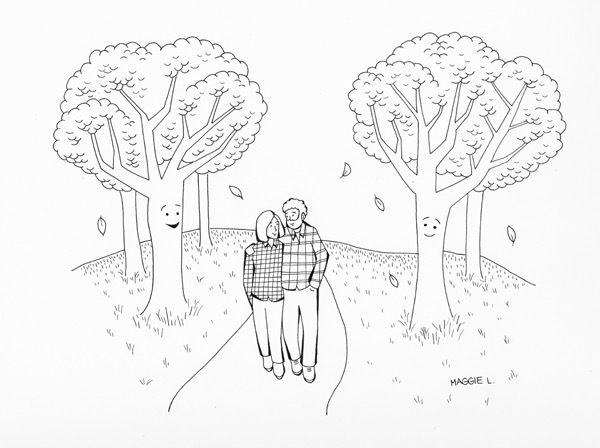

In [94]:
#Select k between 0 and 2600
k=41
img = newyorker491[k]['image']
print(f"Number of dataset entries with this image: {newyorker491[k]['contest_count']}")
img

In [75]:
# Extract the 'scene' data from the dataset
scenes = [entry['scene'] for entry in newyorker491]

In [88]:
from sentence_transformers import SentenceTransformer

# model = SentenceTransformer('sentence-transformers/all-MiniLM-L6-v2')
# model_name="all-MiniLM-L6-v2"

# model= SentenceTransformer("Snowflake/snowflake-arctic-embed-xs")
# model_name="snowflake-arctic-embed-xs"

model = SentenceTransformer("Snowflake/snowflake-arctic-embed-m")
model_name="snowflake-arctic-embed-m"

In [89]:
# Generate sentence embeddings for each scene
##You need to re-execute this when you change the model!

scene_embeddings = model.encode(scenes)

# To associate embeddings with their indices without influencing the embeddings:
indexed_embeddings = list(enumerate(scene_embeddings))


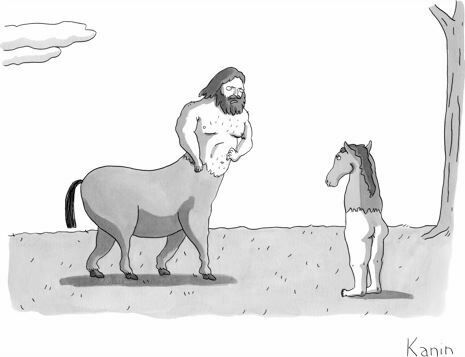

In [90]:
k=1208
image_to_display = newyorker491[k]['image']
display(image_to_display)

In [91]:
my_description = ["A centaur with a human face and a horse body and a centaur with a horse face"]


In [92]:
query_embedding = model.encode(my_description)
# This depends on the model so be sure to re-execute if you have changed the model

In [93]:
# Select the top n
n=8
# Extract just the embeddings from the indexed_embeddings
embeddings = np.array([emb for idx, emb in indexed_embeddings])


# Calculate scores by matrix multiplication of the query_embedding with embeddings transposed
query_scores = query_embedding @ embeddings.T  # This should be a 1D array of scores
query_scores = query_scores.flatten()  # Flatten in case it's not already a 1D array

# Verify the sizes and contents
print(f"Model name: {model_name}")
print("Embeddings shape:", embeddings.shape)
print("Query Embedding shape:", query_embedding.shape)
print("Scores shape:", query_scores.shape)

# Create and sort the document-score pairs
doc_score_pairs = list(zip(indexed_embeddings, query_scores))
doc_score_pairs = sorted(doc_score_pairs, key=lambda x: x[1], reverse=True)


top_n_pairs = doc_score_pairs[:n]

# Output the query and the top passages & scores
query_text = "My description: " + my_description[0]
wrapped_query = textwrap.fill(query_text, width=75)
display(Markdown(wrapped_query))

import textwrap
from IPython.display import Markdown, display

# Display each top passage with index, score, contest number, and description
for ((index, _), score) in top_n_pairs:
    passage = scenes[index]  # Fetching the corresponding scene description
    contest = newyorker491['contest_number'][index]  # Accessing contest number
    # Format the metadata with wrapping
    score_text = f"Score: {score:.4f}, Contest Number: {contest}, Index: {index}:"
    wrapped_score_text = textwrap.fill(score_text, width=70)
    # Format the passage with wrapping
    wrapped_passage = textwrap.fill(passage, width=75)
    # Combine the wrapped text with a double newline for clear separation
    full_text = f"{wrapped_score_text}\n\n{wrapped_passage}"
    # Display using Markdown to preserve formatting
    display(Markdown(full_text))


Model name: snowflake-arctic-embed-m
Embeddings shape: (2601, 768)
Query Embedding shape: (1, 768)
Scores shape: (2601,)


My description: A centaur with a human face and a horse body and a centaur
with a horse face

Score: 0.8239, Contest Number: 206, Index: 2132:

Location: a field. Description: A half man/ half horse meets another half
man half horse but instead of an adult torso and horse legs they are a
horse head and a human body. Entities: Centaur, Role reversal

Score: 0.8149, Contest Number: 206, Index: 267:

Location: forest. Description: A half man/ half horse meets another half
man half horse but instead of an adult torso and horse legs they are a
horse head and a human body. Entities: Centaur, Horse head mask

Score: 0.8083, Contest Number: 206, Index: 257:

Location: a field. Description: Two figures are talking on a field. One is
a centaur, and the other is his opposite, with the back end of a human and
the head of a horse. Entities: Centaur, Role reversal

Score: 0.8003, Contest Number: 718, Index: 1131:

Location: farm. Description: A cowboy is on a ranch. He is looking at a
horse. Entities: Horse, Cowboy

Score: 0.7980, Contest Number: 206, Index: 325:

Location: forest. Description: Two figures are talking on a field. One is a
centaur, and the other is his opposite, with the back end of a human and
the head of a horse. Entities: Centaur, Horse head mask

Score: 0.7818, Contest Number: 335, Index: 1504:

Location: horse track. Description: Some jockeys are in a race. They are
using fake horses. Entities: Horse, Horse racing

Score: 0.7775, Contest Number: 253, Index: 2133:

Location: a desert. Description: Two cowboys are out riding. One of them is
missing his horse. Entities: Horse, Cowboy

Score: 0.7760, Contest Number: 309, Index: 2493:

Location: a roller coaster. Description: Some people are on a roller
coaster ride. Some of them are screaming. Entities: Fear, Calmness